# Minimal example network module

In [1]:
import numpy as np
import copy as cp

from climada.util.constants import SYSTEM_DIR
from climada_petals.engine.networks.nw_base import Network
from climada_petals.engine.networks.nw_preps import simplified_network, ordered_network
from climada_petals.engine.networks.nw_calcs import NetworkCalcs

import cartopy.crs as ccrs
import matplotlib.pyplot as plt


PATH_SAVE = SYSTEM_DIR.joinpath('test_networks')

## Prepare data and preprocess network
This section showcases:
1. How exposure data can be downloaded from OpenStreetMap
2. How the exposure data can be preprocessed and initialized as a Network object
3. How to consolidate the infrastructure network by adding missing physical links between components
4. How to save preprocessed network data to disc

In [2]:
## Some helper functions
import shapely
from pathlib import Path
import climada_petals.engine.networks.nw_utils as nwu
from climada_petals.engine.networks.nw_impacts import LINE_EXPOSURES
from osm_flex import download, extract

def make_shape_from_bonds(bonds:list | tuple):
    """
    Create a rectangular polygon shape from bounding coordinates.

    Parameters
    ----------
    bonds : list of float
        A list containing four float values representing the bounding box
        coordinates in the order [min_x, min_y, max_x, max_y].

    Returns
    -------
    shapely.geometry.Polygon
        A rectangular polygon defined by the given bounding box coordinates.
    """

    return shapely.geometry.box(bonds[0],bonds[1],bonds[2],bonds[3])

def crop_gdf_shape(gdf, shape):
    """
    Crop a GeoDataFrame to a specific shape.
    Args:
        gdf (geopandas.GeoDataFrame): The GeoDataFrame to be cropped.
        shape (shapely.geometry.Polygon): The shape to crop the GeoDataFrame to.
    Returns:
        geopandas.GeoDataFrame: The cropped GeoDataFrame.
    """
    return gdf[gdf.geometry.within(shape)]


def nw_prep(gdf, ci_type, reg_shape):
    """General wrapper function for CI data prep. Calls specific prep functions."""
    #crop to shape
    gdf = crop_gdf_shape(gdf, reg_shape)
    if ci_type in LINE_EXPOSURES:
        network = Network(edges=gdf)
    else:
        network = Network(nodes=gdf)
    network = simplified_network(network)
    network = ordered_network(network, {'ci_type':ci_type})
    return network

def road_prep_osm(reg_shape, path_ctr_dump):
    """Wrapper to prepare roads from osm data"""
    gdf_roads = extract.extract_cis(path_ctr_dump, "road")
    gdf_roads = gdf_roads[gdf_roads.geometry.type=='LineString']
    gdf_roads = gdf_roads[['osm_id','highway', 'geometry']]
    return nw_prep(gdf_roads, "road", reg_shape)

# General infra from OSM
def ci_prep_osm(ci_type, path_ctr_dump, reg_shape):
    """Wrapper to prepare generic point exposures from osm data"""
    gdf_osm = extract.extract_cis(path_ctr_dump, ci_type)
    gdf_osm['geometry'] = gdf_osm.geometry.apply(lambda geom: geom.centroid)
    gdf_osm = gdf_osm[['name', 'geometry']]
    return nw_prep(gdf_osm, ci_type, reg_shape)

def pop_prep(reg_shape, filename, up_fct=1, ppl_ctf=0):
    """Wrapper function to prepare people network data."""
    # Load and process people data
    gdf_people = nwu.load_resampled_raster(PATH_SAVE / filename, up_fct, extent=reg_shape)
    gdf_people['latitude'] = gdf_people.geometry.y
    gdf_people['longitude'] = gdf_people.geometry.x
    pop_thresh = nwu.get_pop_cutoff(gdf_people, ppl_ctf)
    gdf_people['value']=gdf_people['counts']
    gdf_people = gdf_people[gdf_people.value>=pop_thresh].reset_index(drop=True)
    return nw_prep(gdf_people, "people", reg_shape)

In [3]:
#define region
from climada.util import coordinates as u_coords
cntry = 'Sudan'
bonds = [33.1, 19.41666667, 33.45, 19.7] #Abu Hamad
iso3 = u_coords.country_to_iso(cntry)
#reg_shape = u_coords.get_admin1_info([countries])
reg_shape = make_shape_from_bonds(bonds)

/Users/lseverino/miniforge3/envs/climada_nw/lib/python3.11/site-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
extract points: 0it [00:00, ?it/s]
extract multipolygons: 0it [00:11, ?it/s]
topology: 100%|██████████| 827/827 [00:00<00:00, 15181.26it/s]


<Axes: >

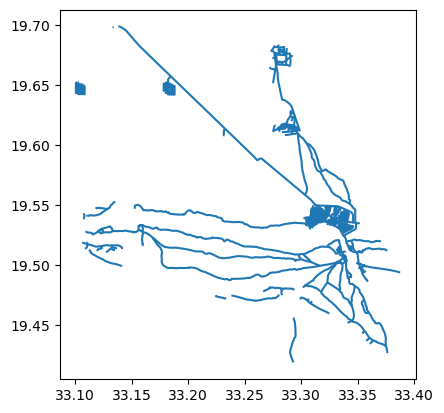

In [4]:
#load ci data using osm_flex
path_ctr_dump = download.get_country_geofabrik(iso3)

#load roads
road_network = road_prep_osm(reg_shape, path_ctr_dump=path_ctr_dump)

#plot
road_network.edges.plot()


2026-09-22 10:14:14,572 - climada_petals.engine.networks.nw_calcs - INFO - Number of clusters in the network before merging: 1426
2026-09-22 10:14:14,574 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: inf
2026-09-22 10:14:20,790 - climada_petals.engine.networks.graph_calcs - INFO - Adding edge distances for new links.
2026-09-22 10:14:20,811 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: inf
2026-09-22 10:14:22,658 - climada_petals.engine.networks.graph_calcs - INFO - Adding edge distances for new links.
2026-09-22 10:14:22,675 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: inf
2026-09-22 10:14:23,097 - climada_petals.engine.networks.graph_calcs - INFO - Adding edge distances for new links.
2026-09-22 10:14:23,1

<Axes: >

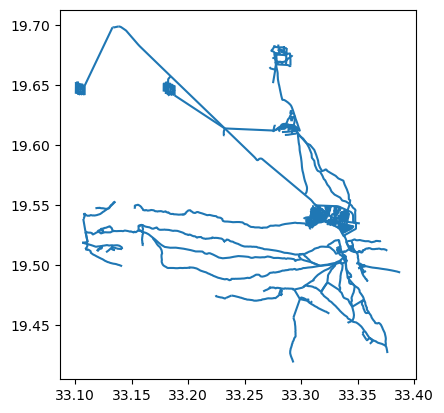

In [5]:
#link clusters
road_nw_calc = NetworkCalcs(road_network)
road_nw_calc.merge_clusters(ci_type="road", max_iter=5, dist_thresh=np.inf)
road_network = road_nw_calc.network
road_network.edges.plot()


extract multipolygons: 100%|██████████| 385/385 [00:19<00:00, 19.31it/s]
endpoints: 0it [00:00, ?it/s]
topology: 0it [00:00, ?it/s]


<Axes: >

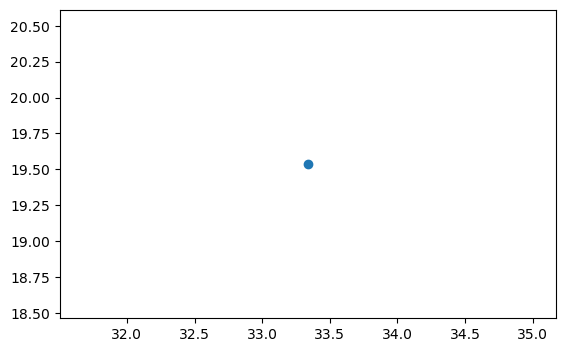

In [6]:
#load healthcare
healthcare_network = ci_prep_osm('healthcare', path_ctr_dump=path_ctr_dump, reg_shape=reg_shape)
healthcare_network.nodes.plot()

/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_utils.py:1242: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdf_people.groupby(pd.cut(gdf_people["counts"], bins)).sum(numeric_only=True)
endpoints: 0it [00:00, ?it/s]
/Users/lseverino/miniforge3/envs/climada_nw/lib/python3.11/site-packages/geopandas/array.py:1754: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))
topology: 0it [00:00, ?it/s]


<Axes: >

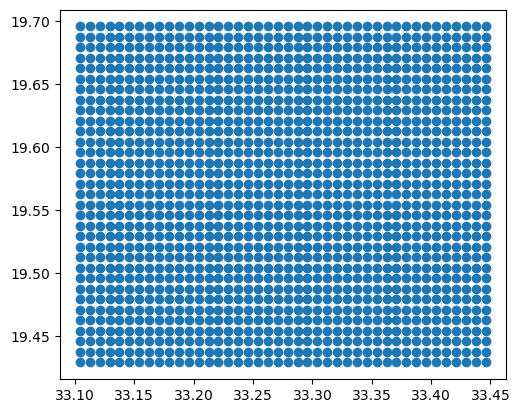

In [7]:
#load people
filename = f'{iso3.lower()}_ppp_2020_1km_Aggregated_UNadj.tif'
if not Path(PATH_SAVE / filename).is_file():
    nwu.get_worldpop_data(iso3, PATH_SAVE, res=1000)
people_network = pop_prep(reg_shape, filename, up_fct=1, ppl_ctf=0)
people_network.nodes.plot()

In [8]:
#combine
network_all = Network.from_networks([road_network, healthcare_network, people_network])

/Users/lseverino/Documents/PhD/workspace/climada_petals/climada_petals/engine/networks/nw_base.py:214: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  edges = pd.concat(edges)


Finally, we consolidate the network by adding physical links between the different network components.
This consists in adding edges of a specific type (e.g. roads, powerlines) to link network components of differing types (e.g. hospitals to road network).
This step is achieved through the use of the add_physical_links method, which requires a physical_dependencies table.

In [9]:
import pandas as pd

physical_dependencies = pd.DataFrame(
    [
        {
            "source": "road",
            "target": "healthcare",
            "link": "road",
            "n_links": 2,
            "thresh_dist": np.inf,
            "bidir_link": False,
        },
        {
            "source": "road",
            "target": "people",
            "link": "road",
            "n_links": 1,
            "thresh_dist": 2000,
            "bidir_link": False,
        },
    ]
)
physical_dependencies

,source,target,link,n_links,thresh_dist,bidir_link
0,road,healthcare,road,2,inf,False
1,road,people,road,1,2000.0,False


In [10]:
# create network calculator
nw_calc = NetworkCalcs(network_all)

# add missing physical links: adds n_links between targets and sources based on link_condition
nw_calc.add_physical_links(physical_dependencies)

# get new network with added links
network_all = nw_calc.network

2026-09-22 10:15:06,861 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: inf
2026-09-22 10:15:06,872 - climada_petals.engine.networks.graph_calcs - INFO - Adding edge distances for new links.
2026-09-22 10:15:06,880 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: 0.017999
2026-09-22 10:15:06,920 - climada_petals.engine.networks.graph_calcs - INFO - Adding edge distances for new links.


Once these steps are done, the user can save the preprocessed network to disc as a zip file

In [11]:
#optionally save network to zip
network_all.save_network_zip(PATH_SAVE, 'network_all_sudan_example')


PosixPath('/Users/lseverino/climada/data/test_networks/network_all_sudan_example.zip')

## Setup network and dependencies
This section showcases:
1. How to load already preprocessed network data
2. How to setup a dependency table
3. How to model network dependencies using the dependency table 
4. How to initialize base state of the network (e.g. function state of the components)
5. How to plot network infrastructure


In [12]:
#read network from zip
network_all = Network.load_network_zip(PATH_SAVE, 'network_all_sudan_example')

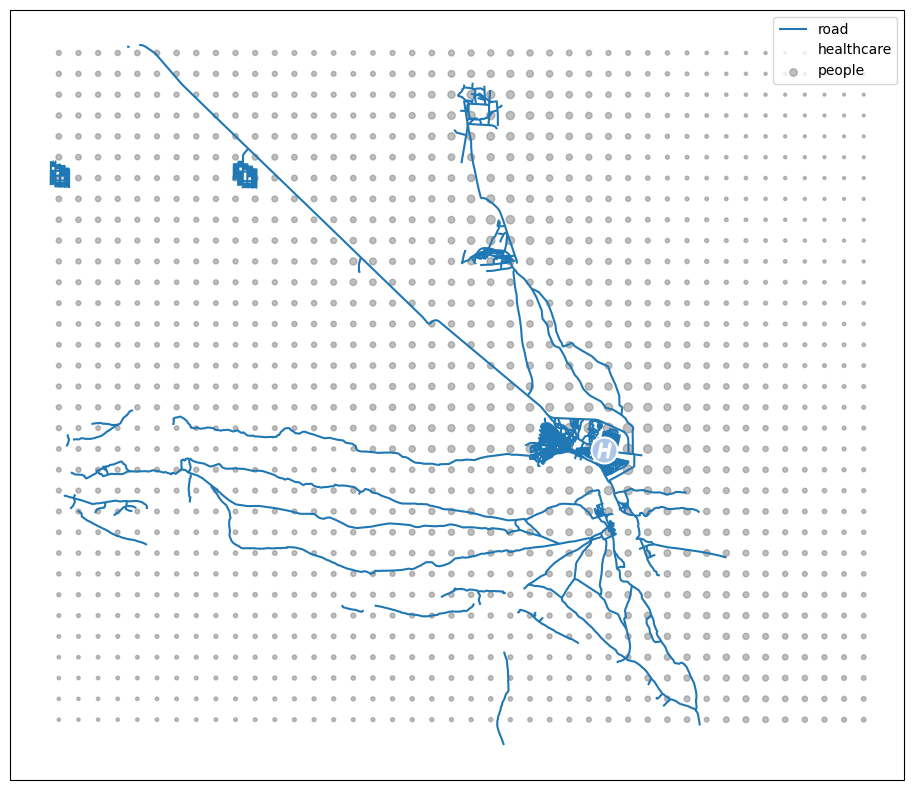

In [13]:
# reproject network for plotting
network_all_rp = Network.reproject(network_all, "EPSG:3857") #returns a new network object, does not modify the original
projection = ccrs.Mercator()

fig, axes = plt.subplots(1, 1, subplot_kw=dict(projection=projection), figsize=(15,10))
fig, axes = network_all_rp.plot_infra(axes=axes, projection=projection, mask_func_ci=False)

To model the dependencies and compute service accessibility, we require a dependency table. A dependency table encodes the relationship between the different network components e.g. what type of relationship (enduser, functional), how to model the relationship (using distance, duration), etc.
- source: name of source CI
- target: name of target CI
- n_links: number of source CI linked to each target CI
- type_I: enduser (target is an enduser of source) or functional (target requires source to function)
- type_II: type of flow between source and target; physical (e.g. units of power) or logical (1 or 0)
- link_condition: method to model source-target dependencies; either distance, duration, or edgecond
    - distance: source-target dependency exists only if source-target distance smaller than thresh_dist
    - duration: source-target dependency exists only if source-target travel duration smaller than thresh_dur
    - edgecond: source-target dependency exists only if an edge exists between source and target
- thresh_func: number of received units of source for target to be functional
- thresh_dist: maximum distance threshold for distance-based source-target dependencies
- thresh_dur: maximum duration threshold for duration-based source-target dependencies
- access_cnstr: whether we require physical access between source and target
- via_link: CI to be used for access-constrained dependencies
- bidir_link: whether CI-CI link should be bidirectional or not (default:False)

In [29]:
import numpy as np
#set up dependency table
def make_dependency_table():
    cols = ['Dep', 'source', 'target', 'n_links', 'access_cnstr', 'type_I',
       'type_II', 'thresh_func', 'thresh_dist', 'thresh_dur', 'conditions',
       'link_condition', 'via_link', 'bidir_link']
    return pd.DataFrame(columns=cols)

df_dependencies = make_dependency_table()

#add dependencies
df_dependencies = pd.DataFrame([
    {
    'Dep': 'dependency_road_healthcare',
    'source': 'road',
    'target': 'healthcare',
    'n_links': 1,
    'access_cnstr': False,
    'type_I': 'functional',
    'type_II': 'logical',
    'thresh_func': 0,
    'thresh_dist': None,
    'thresh_dur': None,
    'link_condition': 'edgecond',
    'via_link': None,
    'bidir_link': False
    },
    {
    'Dep': 'dependency_road_people',
    'source': 'road',
    'target': 'people',
    'n_links': 1,
    'access_cnstr': False,
    'type_I': 'enduser',
    'type_II': 'logical',
    'thresh_func': None,
    'thresh_dist': 2000,
    'thresh_dur': None,
    'link_condition': 'distance',
    'via_link': 'road',
    'bidir_link': False
    },
    {
    'Dep': 'dependency_healthcare_people',
    'source': 'healthcare',
    'target': 'people',
    'n_links': 1,
    'access_cnstr': True,
    'type_I': 'enduser',
    'type_II': 'logical',
    'thresh_func': 1,
    'thresh_dist': 50000,
    'thresh_dur': 90,
    'link_condition': 'distance-duration',
    'via_link': 'road',
    'bidir_link': False
    },])
df_dependencies


,Dep,source,target,n_links,access_cnstr,type_I,type_II,thresh_func,thresh_dist,thresh_dur,link_condition,via_link,bidir_link
0,dependency_road_healthcare,road,healthcare,1,False,functional,logical,0.0,NaN,NaN,edgecond,None,False
1,dependency_road_people,road,people,1,False,enduser,logical,NaN,2000.0,NaN,distance,road,False
2,dependency_healthcare_people,healthcare,people,1,True,enduser,logical,1.0,50000.0,90.0,distance-duration,road,False


In [30]:
# create network calculator with dependency table
nw_calc_test = NetworkCalcs(network_all, dep_table=df_dependencies)

# initialize base state
nw_calc_test.initialize_base_state()

# setup dependencies: model dependencies based on dependency table
nw_calc_test.setup_dependencies()

# finally get the new network with dependencies
network_all = nw_calc_test.network

2026-09-22 10:55:41,396 - climada_petals.engine.networks.graph_calcs - INFO - Adding edge distances for new links.
2026-09-22 10:55:41,424 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: 0.017999
2026-09-22 10:55:41,448 - climada_petals.engine.networks.graph_calcs - INFO - Geographic pre-filter: 487/1386 targets within 0m threshold of sources
2026-09-22 10:55:41,651 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: 0.449964
2026-09-22 10:55:41,660 - climada_petals.engine.networks.graph_calcs - INFO - Geographic pre-filter: 1386/1386 targets within 0m threshold of sources


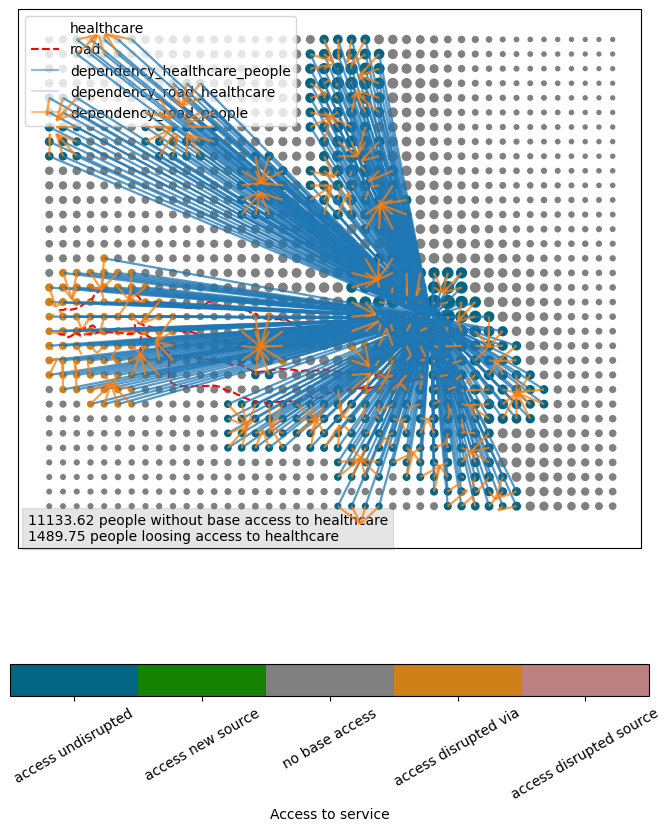

In [31]:
network_all_rp = Network.reproject(network_all, "EPSG:3857")
projection = ccrs.Mercator()
fig, axes = network_all_rp.plot_dep(axes=axes, projection=projection)
fig

## Network service access modelling and cascade
This section showcases:
1. How to model infrastructure interdependencies failures and endusers accesses using the cascade function
2. How to plot access state of the network

cascade function works as follow:
1. Network CIs are updated internally: for roads and power clusters only. For roads: failure of edge propagates to edges' nodes. For power clusters: equalize power demand and provision within a power cluster
2. Update CI-CI functional dependencies: compute cascading failures of CI based on service provision from other CIs
3. Update enduser dependencies: calculates service provision to endusers

In [32]:
#run cascade for base access state
nw_calc_test.cascade()

2026-09-22 10:55:42,093 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: -1
2026-09-22 10:55:42,111 - climada_petals.engine.networks.graph_calcs - INFO - Updating roads
2026-09-22 10:55:42,117 - climada_petals.engine.networks.nw_calcs - INFO - Ended functional state update. Proceeding to end-user update.
2026-09-22 10:55:42,146 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: 0.017999
2026-09-22 10:55:42,169 - climada_petals.engine.networks.graph_calcs - INFO - Geographic pre-filter: 487/1386 targets within 0m threshold of sources
2026-09-22 10:55:42,376 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: 0.449964
2026-09-22 10:55:42,386 - climada_petals.engine.networks.graph_calcs - INFO - Geographic pre-filter: 1386/1386 targets within 0m threshold of sources
2026

(<Figure size 1500x1000 with 2 Axes>, <GeoAxes: >)

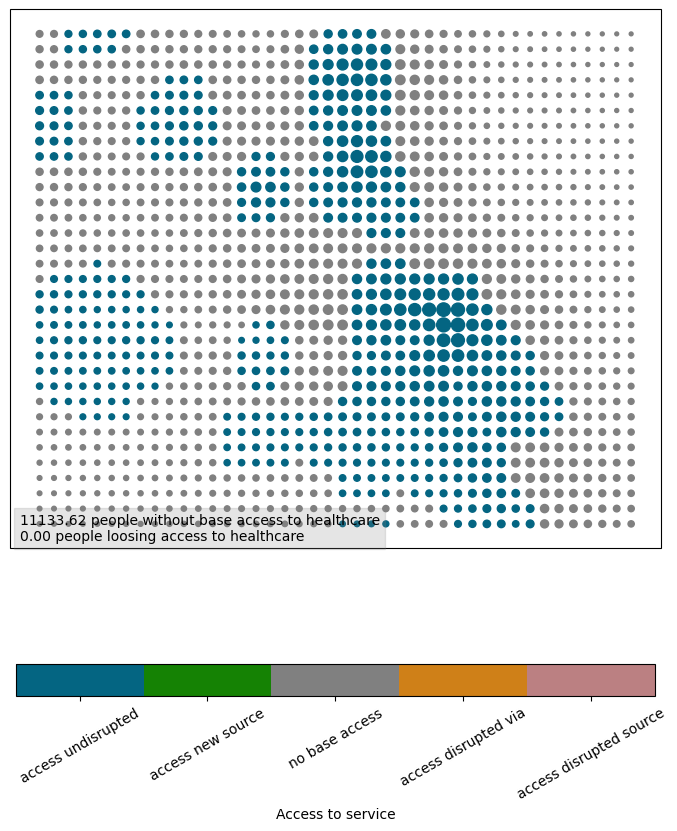

In [33]:
fig, axes = plt.subplots(1, 1, subplot_kw=dict(projection=projection), figsize=(15,10))
from matplotlib.colors import ListedColormap
cascade_network = Network.reproject(nw_calc_test.network, "EPSG:3857")
cascade_network.plot_access('healthcare', axes=axes, projection=projection)

## Network impact calculation
This section showcases:
1. How to load hazard and impact functions that will be used to model impacts on the network's components
2. How to compute impacts on a network object using NetworkImpactCalc class
    1. disagreggate network components to separate point-based climada exposures objects
    2. climada impact calculation on exposures objects
    3. reaggragation of point-based impacts to network components and impact propagation to the network components
4. How to plot effects of natural hazard impacts in terms of infrastructure failures and service access


In [34]:
#load hazard
from climada.hazard.base import Hazard
from climada.util.api_client import Client

client = Client()
rf_dataset_infos = client.list_dataset_infos(data_type="river_flood")


In [35]:
client = Client()
rf_sudan = client.get_hazard(
    "river_flood",
    properties={
        "country_name": "Sudan",
        "climate_scenario": "historical",
        "year_range" : "1980_2000"
    },
)
#rf_sudan.plot_intensity(0);

2026-09-22 10:55:54,356 - climada.hazard.io - INFO - Reading /Users/lseverino/climada/data/hazard/river_flood/river_flood_150arcsec_hist_SDN_1980_2000/v2/river_flood_150arcsec_hist_SDN_1980_2000.hdf5


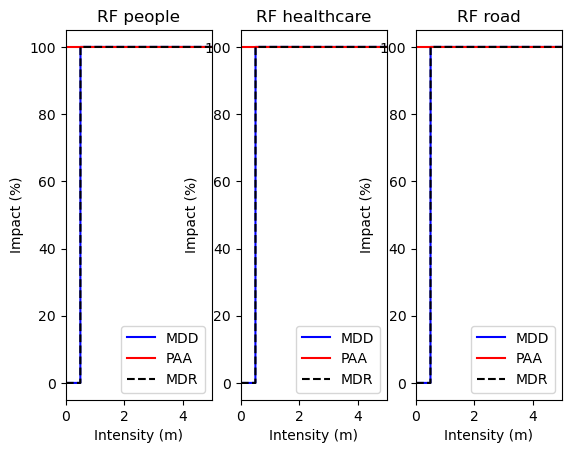

In [36]:
#prepare impact functions
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

#make impact functions
def make_step_impf(thresh, haz_type, ci_type):
        step_impf = ImpactFunc()
        step_impf.id = ci_type
        step_impf.haz_type = haz_type
        step_impf.name = ci_type
        step_impf.intensity_unit = 'm'
        step_impf.intensity = np.array([0, 0.99*thresh, thresh, 2*thresh, 10*thresh])
        step_impf.mdd =       np.array([0, 0, 1, 1,1])
        step_impf.paa =       np.sort(np.linspace(1, 1, num=5))
        step_impf.check()
        return step_impf


impf_set = ImpactFuncSet()
impf_set.append(make_step_impf(0.5, rf_sudan.haz_type, "people"))
impf_set.append(make_step_impf(0.5, rf_sudan.haz_type, "healthcare"))
impf_set.append(make_step_impf(0.5, rf_sudan.haz_type, "road"))
impf_set.plot()

#store functionality thresholds in dict
thresh_func_dict = {"people" : 0.5, "healthcare" : 0.5, "road" : 0.5}

In [37]:
from climada_petals.engine.networks.nw_impacts import exposure_from_edges, exposure_from_nodes
from climada_petals.engine.networks.nw_impacts import NetworkImpactCalc
import copy as cp

#prepare exposures from base network
network_base = cp.deepcopy(nw_calc_test.network)
exp_ppl = exposure_from_nodes(network_base, ci_type="people", value_col="counts")
exp_hc = exposure_from_nodes(network_base, ci_type="healthcare", value=1)
exp_rd = exposure_from_edges(network_base, ci_type="road", res=500)
exp_list = [exp_ppl, exp_hc, exp_rd]


#select hazard, impf
haz = rf_sudan.select(event_id=[1])
impf_set = impf_set
impf_thresh_set = thresh_func_dict

#create nw_impact_object
nw_impact_calc = NetworkImpactCalc(network=network_base, impf_set=impf_set,
                                   impf_thresh_set=impf_thresh_set, haz=haz, exp_list=exp_list)

#run impact calculation
network_disrupted, impact_dict = nw_impact_calc.disrupt_network()

2026-09-22 10:55:54,567 - climada.entity.exposures.base - INFO - Setting latitude and longitude attributes.
2026-09-22 10:55:54,569 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
2026-09-22 10:55:54,569 - climada.entity.exposures.base - INFO - category_id not set.
2026-09-22 10:55:54,570 - climada.entity.exposures.base - INFO - cover not set.
2026-09-22 10:55:54,570 - climada.entity.exposures.base - INFO - deductible not set.
2026-09-22 10:55:54,570 - climada.entity.exposures.base - INFO - region_id not set.
2026-09-22 10:55:54,571 - climada.entity.exposures.base - INFO - centr_ not set.
2026-09-22 10:55:54,573 - climada.entity.exposures.base - INFO - Setting latitude and longitude attributes.
2026-09-22 10:55:54,574 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
2026-09-22 10:55:54,574 - climada.entity.exposures.base - INFO - category_id not set.
2026-09-22 10:55:54,574 - climada.

<GeoAxes: title={'center': 'Expected annual impact'}>

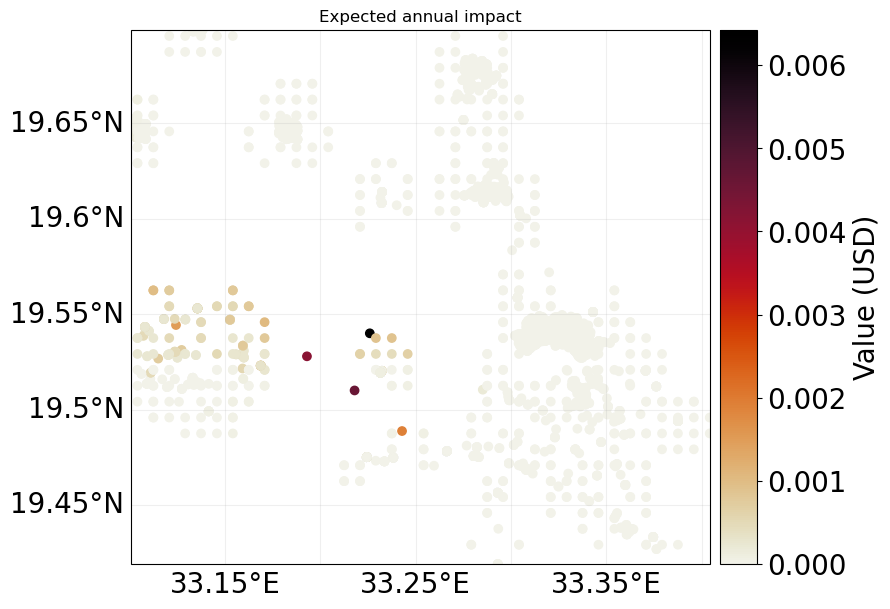

In [38]:
impact_dict["road"].plot_scatter_eai_exposure()

In [39]:
#re run cascade to get indirect cascading impacts
nw_calc_disrupted = NetworkCalcs(network_disrupted, dep_table=df_dependencies)
nw_calc_disrupted.cascade(initial=False)
network_cascade = nw_calc_disrupted.network


2026-09-22 10:55:55,376 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: -1
2026-09-22 10:55:55,392 - climada_petals.engine.networks.graph_calcs - INFO - Updating roads
2026-09-22 10:55:55,398 - climada_petals.engine.networks.nw_calcs - INFO - Updating functional states. Current delta: 19
2026-09-22 10:55:55,399 - climada_petals.engine.networks.graph_calcs - INFO - Updating roads
2026-09-22 10:55:55,404 - climada_petals.engine.networks.nw_calcs - INFO - Ended functional state update. Proceeding to end-user update.
2026-09-22 10:55:55,441 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; automatically converting distance threshold to degrees: 0.017999
2026-09-22 10:55:55,464 - climada_petals.engine.networks.graph_calcs - INFO - Geographic pre-filter: 471/1386 targets within 0m threshold of sources
2026-09-22 10:55:55,666 - climada_petals.engine.networks.graph_calcs - INFO - Network is in geographic CRS; autom

In [40]:
network_cascade_rp = Network.reproject(network_cascade, "EPSG:3857")
projection = ccrs.Mercator()

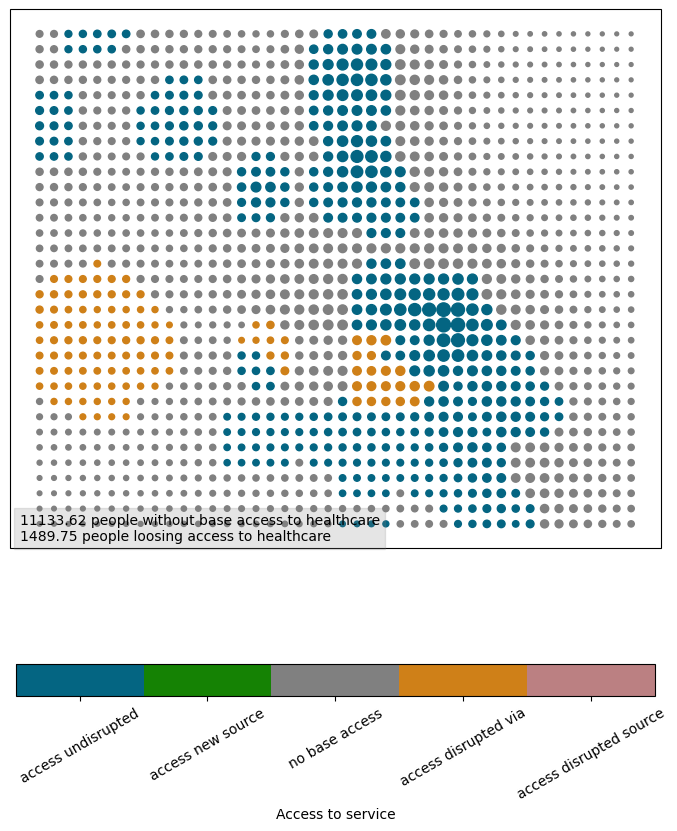

In [41]:
fig, axes = plt.subplots(1, 1, subplot_kw=dict(projection=projection), figsize=(15,10))

fig, axes = network_cascade_rp.plot_access(
    "healthcare", axes=axes, projection=projection
)

In [42]:
plot_col = "func_tot" #to plot functionality states of cis
ci_types_plot = ["healthcare", "road"]
fig, axes = network_cascade_rp.plot_infra(
    axes=axes, ci_types=ci_types_plot, plot_col=plot_col, projection=projection
)

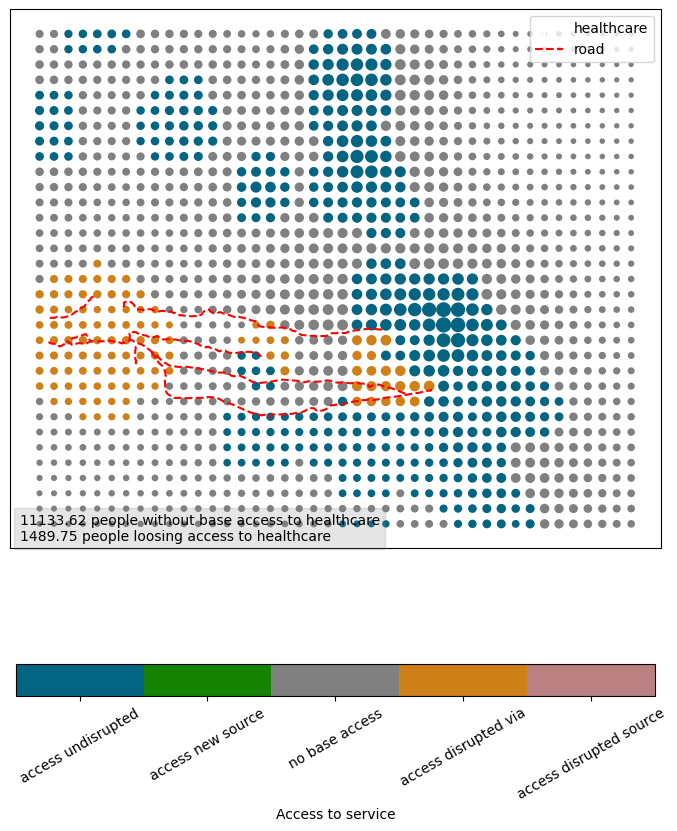

In [43]:
fig